<a href="https://colab.research.google.com/github/chirontan/FEM/blob/main/Q_4___(a%2Cb%2Cc%2Cd).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Solution to Q.4.(a)**

In [5]:
def spring_element(Ui, Uj, ke, alpha):

    delta = Uj - Ui

    q = ke*delta + alpha*delta**3

    fint = q*np.array([-1.0, 1.0])

    kt = (ke + 3*alpha*delta**2) * np.array([
        [1.0, -1.0],
        [-1.0,  1.0]
    ])

    return delta, q, fint, kt

# **Solution to Q.4.(b)**

In [7]:
import numpy as np

# =========================================================
# QUESTION 4(b)
# GLOBAL ASSEMBLY
# =========================================================


# ---------------------------------------------------------
# 1. Element routine from Question 4(a)
# ---------------------------------------------------------

def spring_element(Ui, Uj, ke, alpha):

    # Element deformation
    delta = Uj - Ui

    # Nonlinear spring force
    q = ke * delta + alpha * delta**3

    # Element internal force vector
    fint = q * np.array([-1.0, 1.0])

    # Element tangent stiffness matrix
    kt = (ke + 3.0 * alpha * delta**2) * np.array([
        [1.0, -1.0],
        [-1.0, 1.0]
    ])

    return delta, q, fint, kt


# ---------------------------------------------------------
# 2. Number of nodes
# ---------------------------------------------------------

n_nodes = 4


# ---------------------------------------------------------
# 3. Element connectivity
#
# Python uses numbering 0,1,2,3
#
# Physical:
# Element 1 : Node 1 - Node 2
# Element 2 : Node 2 - Node 3
# Element 3 : Node 3 - Node 4
# Element 4 : Node 2 - Node 4
# ---------------------------------------------------------

elements = np.array([
    [0, 1],   # Element 1
    [1, 2],   # Element 2
    [2, 3],   # Element 3
    [1, 3]    # Element 4
])


# ---------------------------------------------------------
# 4. Element properties
# ---------------------------------------------------------

ke = np.array([
    100.0,
    150.0,
    200.0,
    100.0
])

alpha = np.array([
    1.0,
    2.0,
    1.5,
    1.0
])


# ---------------------------------------------------------
# 5. External force vector
# ---------------------------------------------------------

Fext = np.array([
    0.0,
    10.0,
    20.0,
    40.0
])


# ---------------------------------------------------------
# 6. INITIAL DISPLACEMENT
#
# THIS WAS MISSING IN YOUR CODE
# ---------------------------------------------------------

U = np.zeros(n_nodes)


# ---------------------------------------------------------
# 7. Initialize global internal force vector
# ---------------------------------------------------------

Fint = np.zeros(n_nodes)


# ---------------------------------------------------------
# 8. Initialize global tangent stiffness matrix
# ---------------------------------------------------------

KT = np.zeros((n_nodes, n_nodes))


# ---------------------------------------------------------
# 9. ELEMENT LOOP
# ---------------------------------------------------------

for e in range(4):

    # Get global node numbers
    i = elements[e, 0]
    j = elements[e, 1]

    # Calculate element quantities
    delta, q, fint_e, kt_e = spring_element(
        U[i],
        U[j],
        ke[e],
        alpha[e]
    )

    # -----------------------------------------------------
    # Assemble element force into global force vector
    # -----------------------------------------------------

    Fint[[i, j]] += fint_e

    # -----------------------------------------------------
    # Assemble element tangent stiffness
    # -----------------------------------------------------

    KT[np.ix_([i, j], [i, j])] += kt_e


# ---------------------------------------------------------
# 10. Global residual
# ---------------------------------------------------------

R = Fint - Fext


# ---------------------------------------------------------
# 11. PRINT RESULTS
# ---------------------------------------------------------

print("GLOBAL ASSEMBLY RESULTS")
print("========================")

print("\nInitial displacement vector U:")
print(U)

print("\nGlobal internal force vector Fint:")
print(Fint)

print("\nExternal force vector Fext:")
print(Fext)

print("\nGlobal residual R = Fint - Fext:")
print(R)

print("\nGlobal tangent stiffness matrix KT:")
print(KT)

GLOBAL ASSEMBLY RESULTS

Initial displacement vector U:
[0. 0. 0. 0.]

Global internal force vector Fint:
[0. 0. 0. 0.]

External force vector Fext:
[ 0. 10. 20. 40.]

Global residual R = Fint - Fext:
[  0. -10. -20. -40.]

Global tangent stiffness matrix KT:
[[ 100. -100.    0.    0.]
 [-100.  350. -150. -100.]
 [   0. -150.  350. -200.]
 [   0. -100. -200.  300.]]


# **Solution to Q.4.(c)**

In [8]:
import numpy as np


# =========================================================
# QUESTION 4(c)
# NEWTON-RAPHSON SOLUTION
# =========================================================


# =========================================================
# 1. ELEMENT ROUTINE
#    This is the routine developed in 4(a)
# =========================================================

def spring_element(Ui, Uj, ke, alpha):

    # Element deformation
    delta = Uj - Ui

    # Nonlinear spring force
    q = ke * delta + alpha * delta**3

    # Element internal force vector
    fint = q * np.array([-1.0, 1.0])

    # Element tangent stiffness matrix
    kt = (ke + 3.0 * alpha * delta**2) * np.array([
        [1.0, -1.0],
        [-1.0,  1.0]
    ])

    return delta, q, fint, kt


# =========================================================
# 2. INPUT DATA
#    These are the data given in the question
# =========================================================

# Number of nodes
n_nodes = 4


# ---------------------------------------------------------
# Element connectivity
#
# Element 1: Node 1 - Node 2
# Element 2: Node 2 - Node 3
# Element 3: Node 3 - Node 4
# Element 4: Node 2 - Node 4
#
# Python uses 0,1,2,3 instead of 1,2,3,4
# ---------------------------------------------------------

elements = np.array([
    [0, 1],
    [1, 2],
    [2, 3],
    [1, 3]
])


# ---------------------------------------------------------
# Element stiffness parameters
# ---------------------------------------------------------

ke = np.array([
    100.0,
    150.0,
    200.0,
    100.0
])


# ---------------------------------------------------------
# Nonlinear coefficients
# ---------------------------------------------------------

alpha = np.array([
    1.0,
    2.0,
    1.5,
    1.0
])


# ---------------------------------------------------------
# External force vector
#
# F1 = 0
# F2 = 10 N
# F3 = 20 N
# F4 = 40 N
# ---------------------------------------------------------

Fext = np.array([
    0.0,
    10.0,
    20.0,
    40.0
])


# =========================================================
# 3. BOUNDARY CONDITIONS
# =========================================================

# Node 1 is fixed:
#
# U1 = 0
#
# Therefore:
# prescribed DOF = 0
#
# Free DOFs = Nodes 2,3,4
# In Python numbering = 1,2,3

prescribed = [0]

free = [1, 2, 3]


# =========================================================
# 4. INITIAL DISPLACEMENT
# =========================================================

U = np.zeros(n_nodes)


# Therefore:
#
# U = [0, 0, 0, 0]
#
# U1 is fixed at zero.
# U2, U3, U4 initially are also zero.


# =========================================================
# 5. NEWTON-RAPHSON PARAMETERS
# =========================================================

tol = 1e-8

max_iter = 50


# Norm of external force vector at free DOFs

Fext_f = Fext[free]

Fext_norm = np.linalg.norm(Fext_f)


# =========================================================
# 6. STORE NEWTON ITERATION HISTORY
# =========================================================

history = []


# =========================================================
# 7. NEWTON-RAPHSON LOOP
# =========================================================

converged = False


for k in range(max_iter):


    # -----------------------------------------------------
    # STEP 1:
    # Initialize global internal force vector
    # -----------------------------------------------------

    Fint = np.zeros(n_nodes)


    # -----------------------------------------------------
    # STEP 2:
    # Initialize global tangent stiffness matrix
    # -----------------------------------------------------

    KT = np.zeros((n_nodes, n_nodes))


    # -----------------------------------------------------
    # STEP 3:
    # ELEMENT LOOP
    #
    # Calculate element quantities and assemble
    # -----------------------------------------------------

    for e in range(len(elements)):

        # Global node numbers
        i = elements[e, 0]
        j = elements[e, 1]


        # Element routine
        delta, q, fint_e, kt_e = spring_element(
            U[i],
            U[j],
            ke[e],
            alpha[e]
        )


        # -------------------------------------------------
        # Assemble internal force
        # -------------------------------------------------

        Fint[[i, j]] += fint_e


        # -------------------------------------------------
        # Assemble tangent stiffness
        # -------------------------------------------------

        KT[np.ix_([i, j], [i, j])] += kt_e


    # -----------------------------------------------------
    # STEP 4:
    # Calculate residual
    #
    # R = Fint - Fext
    # -----------------------------------------------------

    R = Fint - Fext


    # -----------------------------------------------------
    # STEP 5:
    # Extract free-node residual
    #
    # Nodes 2,3,4
    # -----------------------------------------------------

    Rf = R[free]


    # -----------------------------------------------------
    # STEP 6:
    # Calculate convergence measure
    #
    # ||Rf|| / ||Fext,f||
    # -----------------------------------------------------

    residual_norm = np.linalg.norm(Rf)

    residual_ratio = residual_norm / Fext_norm


    # -----------------------------------------------------
    # STEP 7:
    # Check convergence
    # -----------------------------------------------------

    if residual_ratio < tol:

        # No additional Newton correction is calculated
        # after convergence.

        history.append([
            k,
            U[1],
            U[2],
            U[3],
            residual_norm,
            np.nan
        ])

        converged = True

        break


    # -----------------------------------------------------
    # STEP 8:
    # Extract free-free tangent matrix
    #
    # K_T,ff
    # -----------------------------------------------------

    Kff = KT[np.ix_(free, free)]


    # -----------------------------------------------------
    # STEP 9:
    # Solve Newton equation
    #
    # Kff * DeltaU = -Rf
    # -----------------------------------------------------

    delta_U = np.linalg.solve(
        Kff,
        -Rf
    )


    # -----------------------------------------------------
    # STEP 10:
    # Correction norm
    # -----------------------------------------------------

    correction_norm = np.linalg.norm(delta_U)


    # -----------------------------------------------------
    # STEP 11:
    # Store iteration history
    # -----------------------------------------------------

    history.append([
        k,
        U[1],
        U[2],
        U[3],
        residual_norm,
        correction_norm
    ])


    # -----------------------------------------------------
    # STEP 12:
    # Update free displacement vector
    #
    # Uf(k+1) = Uf(k) + DeltaU(k)
    # -----------------------------------------------------

    U[free] = U[free] + delta_U


# =========================================================
# 8. WARNING IF NOT CONVERGED
# =========================================================

if not converged:

    print("\nWARNING:")
    print("Newton-Raphson did not converge")
    print("within", max_iter, "iterations.")


# =========================================================
# 9. PRINT FINAL SOLUTION
# =========================================================

print("\n======================================")
print("QUESTION 4(c)")
print("NEWTON-RAPHSON SOLUTION")
print("======================================")


print("\nConverged:", converged)

print("\nFinal displacement vector:")
print(U)


print("\nFinal displacements:")

print(f"U1 = {U[0]:.10f} mm")
print(f"U2 = {U[1]:.10f} mm")
print(f"U3 = {U[2]:.10f} mm")
print(f"U4 = {U[3]:.10f} mm")


# =========================================================
# 10. PRINT ITERATION HISTORY
# =========================================================

print("\n")
print("Newton-Raphson Iteration History")
print("-------------------------------------------------------------")
print(" k       U2          U3          U4       ||Rf||2    ||dU||2")
print("-------------------------------------------------------------")


for row in history:

    k = int(row[0])

    U2 = row[1]
    U3 = row[2]
    U4 = row[3]

    Rnorm = row[4]
    dUnorm = row[5]


    if np.isnan(dUnorm):

        print(
            f"{k:2d}   "
            f"{U2: .8f}   "
            f"{U3: .8f}   "
            f"{U4: .8f}   "
            f"{Rnorm:.5e}      -"
        )

    else:

        print(
            f"{k:2d}   "
            f"{U2: .8f}   "
            f"{U3: .8f}   "
            f"{U4: .8f}   "
            f"{Rnorm:.5e}   "
            f"{dUnorm:.5e}"
        )


QUESTION 4(c)
NEWTON-RAPHSON SOLUTION

Converged: True

Final displacement vector:
[0.         0.69661945 0.91184736 0.97336624]

Final displacements:
U1 = 0.0000000000 mm
U2 = 0.6966194544 mm
U3 = 0.9118473587 mm
U4 = 0.9733662408 mm


Newton-Raphson Iteration History
-------------------------------------------------------------
 k       U2          U3          U4       ||Rf||2    ||dU||2
-------------------------------------------------------------
 0    0.00000000    0.00000000    0.00000000   4.58258e+01   1.51073e+00
 1    0.70000000    0.91538462    0.97692308   3.03188e-01   6.04867e-03
 2    0.69661969    0.91184760    0.97336648   2.38995e-05   4.09260e-07
 3    0.69661945    0.91184736    0.97336624   1.25356e-13      -


# **Solution to Q.4.(d) and also 4d(i) and 4d(ii)**

1.   List item
2.   List item




QUESTION 4(d)
FINAL CONVERGED RESULTS

Final displacement vector:
[0.         0.69661945 0.91184736 0.97336624]

Final nodal displacements:
U1 = 0.0000000000 mm
U2 = 0.6966194544 mm
U3 = 0.9118473587 mm
U4 = 0.9733662408 mm

ELEMENT RESULTS

Element     Nodes       delta_e (mm)       q_e (N)
------------------------------------------------------
  1        1-2        0.6966194544        70.0000000000
  2        2-3        0.2152279042        32.3041256622
  3        3-4        0.0615188821        12.3041256622
  4        2-4        0.2767467864        27.6958743378

FINAL FORCE BALANCE

Fint =
[-70.  10.  20.  40.]

Fext =
[ 0. 10. 20. 40.]

R = Fint - Fext =
[-7.00000000e+01  1.24344979e-13 -1.42108547e-14  7.10542736e-15]

Support reaction at Node 1:
R1 = -70.0000000000 N

4(d)(i)
EQUILIBRIUM AT CONVERGED FREE NODES

Residual at free nodes:
[ 1.24344979e-13 -1.42108547e-14  7.10542736e-15]

Individual free-node residuals:
R2 = 1.243449787580e-13
R3 = -1.421085471520e-14
R4 = 7.10542

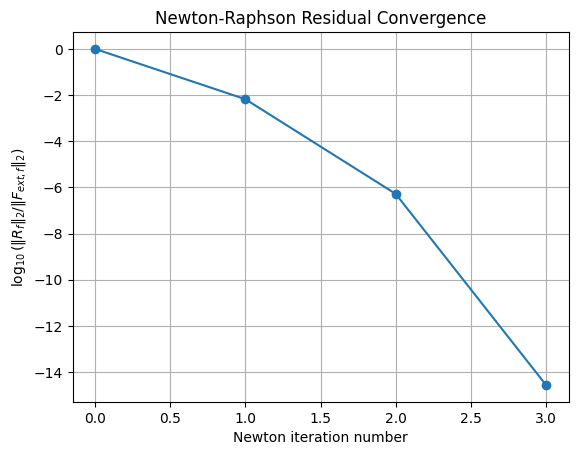

In [9]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# QUESTION 4(d)
# FINAL RESULTS AND EQUILIBRIUM VERIFICATION
# =========================================================


# ---------------------------------------------------------
# FINAL CONVERGED DISPLACEMENTS
# ---------------------------------------------------------

print("\n==========================================")
print("QUESTION 4(d)")
print("FINAL CONVERGED RESULTS")
print("==========================================")


print("\nFinal displacement vector:")

print(U)


print("\nFinal nodal displacements:")

print(f"U1 = {U[0]:.10f} mm")
print(f"U2 = {U[1]:.10f} mm")
print(f"U3 = {U[2]:.10f} mm")
print(f"U4 = {U[3]:.10f} mm")


# =========================================================
# ELEMENT DEFORMATIONS AND FORCES
# =========================================================

print("\n==========================================")
print("ELEMENT RESULTS")
print("==========================================")

print("\nElement     Nodes       delta_e (mm)       q_e (N)")
print("------------------------------------------------------")


element_deformations = []
element_forces = []


for e in range(len(elements)):

    i = elements[e, 0]
    j = elements[e, 1]

    # Element deformation
    delta = U[j] - U[i]

    # Nonlinear element force
    q = ke[e] * delta + alpha[e] * delta**3

    element_deformations.append(delta)
    element_forces.append(q)

    print(
        f"{e+1:3d}        "
        f"{i+1}-{j+1}       "
        f"{delta: .10f}       "
        f"{q: .10f}"
    )


# =========================================================
# REASSEMBLE FINAL INTERNAL FORCE VECTOR
# =========================================================

Fint_final = np.zeros(n_nodes)


for e in range(len(elements)):

    i = elements[e, 0]
    j = elements[e, 1]

    delta = U[j] - U[i]

    q = ke[e] * delta + alpha[e] * delta**3

    fint_e = q * np.array([-1.0, 1.0])

    Fint_final[[i, j]] += fint_e


# =========================================================
# FINAL RESIDUAL
# =========================================================

R_final = Fint_final - Fext


print("\n==========================================")
print("FINAL FORCE BALANCE")
print("==========================================")

print("\nFint =")
print(Fint_final)

print("\nFext =")
print(Fext)

print("\nR = Fint - Fext =")
print(R_final)


# =========================================================
# SUPPORT REACTION
# =========================================================

R1 = R_final[0]

print("\nSupport reaction at Node 1:")

print(f"R1 = {R1:.10f} N")


# =========================================================
# 4(d)(i)
# EQUILIBRIUM AT CONVERGED FREE NODES
# =========================================================

print("\n==========================================")
print("4(d)(i)")
print("EQUILIBRIUM AT CONVERGED FREE NODES")
print("==========================================")


# Free nodes are Nodes 2, 3 and 4
free = [1, 2, 3]

R_free = R_final[free]

R_free_norm = np.linalg.norm(R_free)


print("\nResidual at free nodes:")

print(R_free)


print("\nIndividual free-node residuals:")

print(f"R2 = {R_final[1]:.12e}")
print(f"R3 = {R_final[2]:.12e}")
print(f"R4 = {R_final[3]:.12e}")


print("\n||Rf||2 =")

print(f"{R_free_norm:.12e}")


if R_free_norm < 1e-8:

    print("\nRESULT:")
    print("Equilibrium at the converged free nodes is satisfied.")

else:

    print("\nRESULT:")
    print("Equilibrium at the converged free nodes is NOT satisfied.")


# =========================================================
# 4(d)(ii)
# OVERALL GLOBAL FORCE EQUILIBRIUM
# =========================================================

print("\n==========================================")
print("4(d)(ii)")
print("OVERALL GLOBAL FORCE EQUILIBRIUM")
print("==========================================")


F2 = Fext[1]
F3 = Fext[2]
F4 = Fext[3]


global_equilibrium = R1 + F2 + F3 + F4


print("\nR1 =", R1)
print("F2 =", F2)
print("F3 =", F3)
print("F4 =", F4)


print("\nChecking:")

print("R1 + F2 + F3 + F4 =")

print(
    f"{R1:.10f} + "
    f"{F2:.10f} + "
    f"{F3:.10f} + "
    f"{F4:.10f}"
)


print("\nResult:")

print(
    f"R1 + F2 + F3 + F4 = "
    f"{global_equilibrium:.12e}"
)


if abs(global_equilibrium) < 1e-8:

    print("\nRESULT:")
    print("Overall global force equilibrium is satisfied.")

else:

    print("\nRESULT:")
    print("Overall global force equilibrium is NOT satisfied.")


# =========================================================
# NEWTON-RAPHSON ITERATION HISTORY
# =========================================================

print("\n==========================================")
print("NEWTON-RAPHSON ITERATION HISTORY")
print("==========================================")


print(
    "\n k        U2          U3          U4"
    "          ||Rf||2       ||dU||2"
)

print(
    "-----------------------------------------------------------"
)


for row in history:

    k = int(row[0])

    U2 = row[1]
    U3 = row[2]
    U4 = row[3]

    Rnorm = row[4]
    dUnorm = row[5]


    if np.isnan(dUnorm):

        print(
            f"{k:2d}   "
            f"{U2: .8f}   "
            f"{U3: .8f}   "
            f"{U4: .8f}   "
            f"{Rnorm:.5e}       -"
        )

    else:

        print(
            f"{k:2d}   "
            f"{U2: .8f}   "
            f"{U3: .8f}   "
            f"{U4: .8f}   "
            f"{Rnorm:.5e}   "
            f"{dUnorm:.5e}"
        )


# =========================================================
# RESIDUAL CONVERGENCE PLOT
#
# Assignment asks for:
#
# log10( ||Rf||2 / ||Fext,f||2 )
#
# versus Newton iteration number
# =========================================================

Fext_free = Fext[free]

Fext_free_norm = np.linalg.norm(Fext_free)


iteration_numbers = []

residual_ratios = []


for row in history:

    k = int(row[0])

    Rnorm = row[4]

    ratio = Rnorm / Fext_free_norm

    iteration_numbers.append(k)

    residual_ratios.append(ratio)


plt.figure()

plt.plot(
    iteration_numbers,
    np.log10(residual_ratios),
    "o-"
)

plt.xlabel("Newton iteration number")

plt.ylabel(
    r"$\log_{10}(\|R_f\|_2/\|F_{ext,f}\|_2)$"
)

plt.title("Newton-Raphson Residual Convergence")

plt.grid(True)

plt.show()